In [ ]:
from google.colab import drive; drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp "/content/drive/MyDrive/training_colab.zip" /content/

In [ ]:
!unzip -q /content/training_colab.zip -d /content
%cd /content/training
!apt-get -qq install build-essential >/dev/null 2>&1
!bash build_parser.sh                 # Linux .so 생성
!pip -q install scikit-learn joblib
import numpy as np, glob
for f in sorted(glob.glob('data/*/X_benign.npy')): print(f, np.load(f).shape)

/content/training
built: /content/training/packet_parser_stack.so
data/auth/X_benign.npy (60000, 1479, 5)
data/comment/X_benign.npy (60000, 1479, 5)
data/frontend/X_benign.npy (18675, 1479, 5)
data/mysql/X_benign.npy (60000, 1479, 5)
data/post/X_benign.npy (60000, 1479, 5)


In [ ]:
import numpy as np
brute=np.load('data/_attack/X_brute.npy'); k8s=np.load('data/_attack/X_k8s.npy')
np.save('data/auth/X_attack.npy', np.concatenate([brute,k8s]))
for s in ['post','comment','frontend','mysql']: np.save(f'data/{s}/X_attack.npy', k8s)
print('X_attack.npy 생성 완료')

X_attack.npy 생성 완료


In [ ]:
# 크기 스윕 (shallow teacher)
!python sweep_sizes.py --data data/auth --out models/auth_sweep --teacher shallow --limit 50000


[sweep] student 1x8  (1.23K params)
[pipeline] data/auth → models/auth_sweep/1x8 | device=cuda | mask=ON
[마스킹] 전송계층(window/urgptr/seq/ack, rows 7-18) 마스킹 = ON (MASK_TRANSPORT)
[data] benign total=50000 (sessions=911) → train=34945 val=15055 (세션분할=ON, VEC_LEN=1479)
  [teacher 1/30] nt_xent=3.4390
  [teacher 2/30] nt_xent=2.5766
  [teacher 3/30] nt_xent=2.2470
  [teacher 4/30] nt_xent=1.9068
  [teacher 5/30] nt_xent=1.6707
  [teacher 6/30] nt_xent=1.5294
  [teacher 7/30] nt_xent=1.4026
  [teacher 8/30] nt_xent=1.3241
  [teacher 9/30] nt_xent=1.2898
  [teacher 10/30] nt_xent=1.2521
  [teacher 11/30] nt_xent=1.2352
  [teacher 12/30] nt_xent=1.1899
  [teacher 13/30] nt_xent=1.1680
  [teacher 14/30] nt_xent=1.1440
  [teacher 15/30] nt_xent=1.1259
  [teacher 16/30] nt_xent=1.1142
  [teacher 17/30] nt_xent=1.0994
  [teacher 18/30] nt_xent=1.0895
  [teacher 19/30] nt_xent=1.0878
  [teacher 20/30] nt_xent=1.0778
  [teacher 21/30] nt_xent=1.0730
  [teacher 22/30] nt_xent=1.0613
  [teacher 23/30]

In [ ]:
# 크기 스윕 (shallow teacher)
!python sweep_sizes.py --data data/post --out models/post_sweep --teacher shallow --limit 50000


[sweep] student 1x8  (1.23K params)
[pipeline] data/post → models/post_sweep/1x8 | device=cuda | mask=ON
[마스킹] 전송계층(window/urgptr/seq/ack, rows 7-18) 마스킹 = ON (MASK_TRANSPORT)
[data] benign total=50000 (sessions=207) → train=31572 val=18428 (세션분할=ON, VEC_LEN=1479)
  [teacher 1/30] nt_xent=3.5220
  [teacher 2/30] nt_xent=2.8132
  [teacher 3/30] nt_xent=2.4450
  [teacher 4/30] nt_xent=2.1763
  [teacher 5/30] nt_xent=1.9756
  [teacher 6/30] nt_xent=1.8213
  [teacher 7/30] nt_xent=1.7175
  [teacher 8/30] nt_xent=1.6711
  [teacher 9/30] nt_xent=1.6275
  [teacher 10/30] nt_xent=1.6004
  [teacher 11/30] nt_xent=1.5974
  [teacher 12/30] nt_xent=1.5724
  [teacher 13/30] nt_xent=1.5609
  [teacher 14/30] nt_xent=1.5494
  [teacher 15/30] nt_xent=1.5320
  [teacher 16/30] nt_xent=1.5329
  [teacher 17/30] nt_xent=1.5192
  [teacher 18/30] nt_xent=1.5096
  [teacher 19/30] nt_xent=1.5142
  [teacher 20/30] nt_xent=1.5051
  [teacher 21/30] nt_xent=1.5009
  [teacher 22/30] nt_xent=1.4998
  [teacher 23/30]

In [ ]:
# 크기 스윕 (shallow teacher)
!python sweep_sizes.py --data data/comment --out models/comment_sweep --teacher shallow --limit 50000


[sweep] student 1x8  (1.23K params)
[pipeline] data/comment → models/comment_sweep/1x8 | device=cuda | mask=ON
[마스킹] 전송계층(window/urgptr/seq/ack, rows 7-18) 마스킹 = ON (MASK_TRANSPORT)
[data] benign total=50000 (sessions=265) → train=32441 val=17559 (세션분할=ON, VEC_LEN=1479)
  [teacher 1/30] nt_xent=3.9344
  [teacher 2/30] nt_xent=3.4519
  [teacher 3/30] nt_xent=3.2075
  [teacher 4/30] nt_xent=2.9508
  [teacher 5/30] nt_xent=2.7460
  [teacher 6/30] nt_xent=2.6053
  [teacher 7/30] nt_xent=2.4870
  [teacher 8/30] nt_xent=2.4139
  [teacher 9/30] nt_xent=2.3783
  [teacher 10/30] nt_xent=2.3519
  [teacher 11/30] nt_xent=2.3276
  [teacher 12/30] nt_xent=2.3046
  [teacher 13/30] nt_xent=2.3014
  [teacher 14/30] nt_xent=2.2843
  [teacher 15/30] nt_xent=2.2711
  [teacher 16/30] nt_xent=2.2513
  [teacher 17/30] nt_xent=2.2414
  [teacher 18/30] nt_xent=2.2339
  [teacher 19/30] nt_xent=2.2193
  [teacher 20/30] nt_xent=2.2161
  [teacher 21/30] nt_xent=2.2015
  [teacher 22/30] nt_xent=2.1963
  [teacher 

In [ ]:
# 크기 스윕 (shallow teacher)
!python sweep_sizes.py --data data/frontend --out models/frontend_sweep --teacher shallow --limit 50000


[sweep] student 1x8  (1.23K params)
[pipeline] data/frontend → models/frontend_sweep/1x8 | device=cuda | mask=ON
[마스킹] 전송계층(window/urgptr/seq/ack, rows 7-18) 마스킹 = ON (MASK_TRANSPORT)
[data] benign total=18675 (sessions=173) → train=16583 val=2092 (세션분할=ON, VEC_LEN=1479)
  [teacher 1/30] nt_xent=3.2700
  [teacher 2/30] nt_xent=2.8799
  [teacher 3/30] nt_xent=2.7310
  [teacher 4/30] nt_xent=2.6279
  [teacher 5/30] nt_xent=2.5136
  [teacher 6/30] nt_xent=2.4495
  [teacher 7/30] nt_xent=2.3888
  [teacher 8/30] nt_xent=2.3476
  [teacher 9/30] nt_xent=2.3389
  [teacher 10/30] nt_xent=2.3127
  [teacher 11/30] nt_xent=2.2885
  [teacher 12/30] nt_xent=2.2847
  [teacher 13/30] nt_xent=2.2736
  [teacher 14/30] nt_xent=2.2592
  [teacher 15/30] nt_xent=2.2522
  [teacher 16/30] nt_xent=2.2457
  [teacher 17/30] nt_xent=2.2392
  [teacher 18/30] nt_xent=2.2334
  [teacher 19/30] nt_xent=2.2271
  [teacher 20/30] nt_xent=2.2327
  [teacher 21/30] nt_xent=2.2096
  [teacher 22/30] nt_xent=2.2117
  [teacher

In [ ]:
# 크기 스윕 (shallow teacher)
!python sweep_sizes.py --data data/mysql --out models/mysql_sweep --teacher shallow --limit 50000

In [ ]:
# 배포모델 2x8 전 서비스 학습 (마스킹 ON)
for s in ['auth','post','comment','frontend','mysql']:
    !MASK_TRANSPORT=1 python train_kd_pipeline.py --data data/{s} --out models/{s} --arch 2x8 --teacher shallow --limit 50000

[pipeline] data/auth → models/auth | device=cuda | mask=ON
[마스킹] 전송계층(window/urgptr/seq/ack, rows 7-18) 마스킹 = ON (MASK_TRANSPORT)
[data] benign total=50000 (sessions=911) → train=34945 val=15055 (세션분할=ON, VEC_LEN=1479)
  [teacher 1/30] nt_xent=3.4023
  [teacher 2/30] nt_xent=2.4520
  [teacher 3/30] nt_xent=1.9912
  [teacher 4/30] nt_xent=1.6839
  [teacher 5/30] nt_xent=1.5114
  [teacher 6/30] nt_xent=1.4120
  [teacher 7/30] nt_xent=1.3155
  [teacher 8/30] nt_xent=1.2274
  [teacher 9/30] nt_xent=1.1697
  [teacher 10/30] nt_xent=1.1246
  [teacher 11/30] nt_xent=1.0922
  [teacher 12/30] nt_xent=1.0635
  [teacher 13/30] nt_xent=1.0379
  [teacher 14/30] nt_xent=1.0254
  [teacher 15/30] nt_xent=1.0049
  [teacher 16/30] nt_xent=1.0022
  [teacher 17/30] nt_xent=0.9881
  [teacher 18/30] nt_xent=0.9768
  [teacher 19/30] nt_xent=0.9760
  [teacher 20/30] nt_xent=0.9661
  [teacher 21/30] nt_xent=0.9629
  [teacher 22/30] nt_xent=0.9527
  [teacher 23/30] nt_xent=0.9497
  [teacher 24/30] nt_xent=0.947

In [ ]:
# held-out 평가 (test/benign FPR + attack recall)
import numpy as np, torch, joblib, json, os
from student_cnn import make_student
from data_utils import apply_transport_mask
from sklearn.metrics import roc_auc_score
def load(p):
    X=np.load(p).astype(np.float32); X=X/255 if X.max()>1.5 else X
    return apply_transport_mask(X)
def emb(m,X,bs=2048):
    m.eval(); out=[]
    with torch.no_grad():
        for i in range(0,len(X),bs):
            out.append(m(torch.from_numpy(X[i:i+bs]).unsqueeze(1)).cpu().numpy())
    return np.concatenate(out)
def ev(svc, attacks, arch='2x8', root='models'):
    d=f'{root}/{svc}'
    st=make_student(arch); st.load_state_dict(torch.load(f'{d}/student.pth')['state_dict'])
    oc=joblib.load(f'{d}/ocsvm.pkl'); thr=json.load(open(f'{d}/threshold.json'))['threshold_df']
    fb=oc.decision_function(emb(st,load(f'data/{svc}/X_testbenign.npy'))); fpr=float((fb<thr).mean())
    for a in attacks:
        fa=oc.decision_function(emb(st,load(f'data/_attack/X_{a}.npy'))); rec=float((fa<thr).mean())
        auc=roc_auc_score(np.r_[np.zeros(len(fb)),np.ones(len(fa))], np.r_[-fb,-fa])
        print(f'{svc:9} vs {a:6}  ROC-AUC={auc:.3f}  FPR={fpr:.3f}  Recall={rec:.3f}')
ev('auth', ['brute','k8s'])
for s in ['post','comment','frontend','mysql']: ev(s, ['k8s'])

[마스킹] 전송계층(window/urgptr/seq/ack, rows 7-18) 마스킹 = ON (MASK_TRANSPORT)
auth      vs brute   ROC-AUC=0.925  FPR=0.116  Recall=0.971
auth      vs k8s     ROC-AUC=0.961  FPR=0.116  Recall=1.000
post      vs k8s     ROC-AUC=1.000  FPR=0.065  Recall=1.000
comment   vs k8s     ROC-AUC=1.000  FPR=0.011  Recall=1.000
frontend  vs k8s     ROC-AUC=0.999  FPR=0.025  Recall=0.997
mysql     vs k8s     ROC-AUC=0.999  FPR=0.010  Recall=0.997


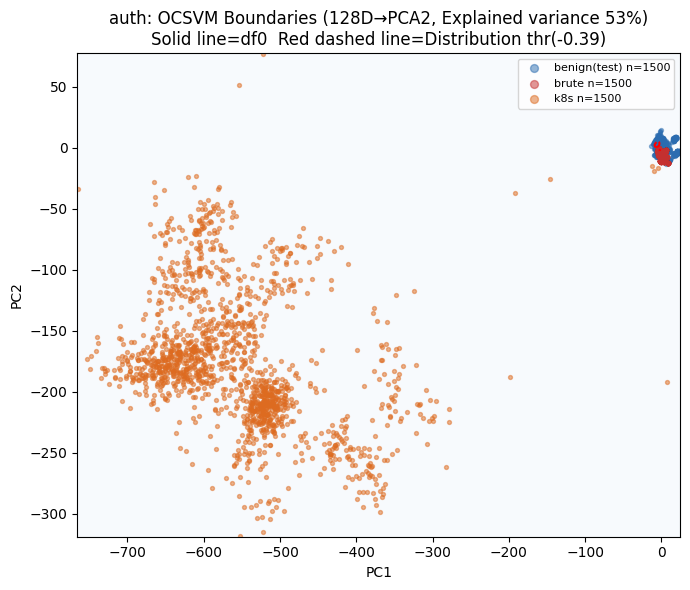

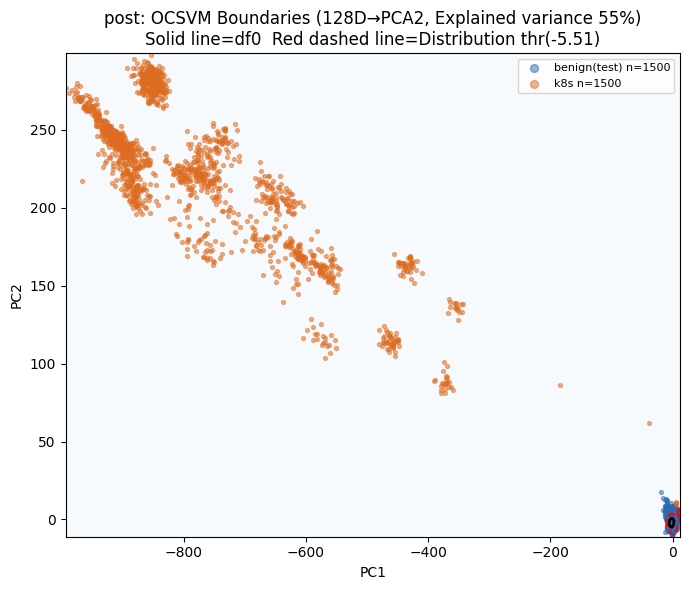

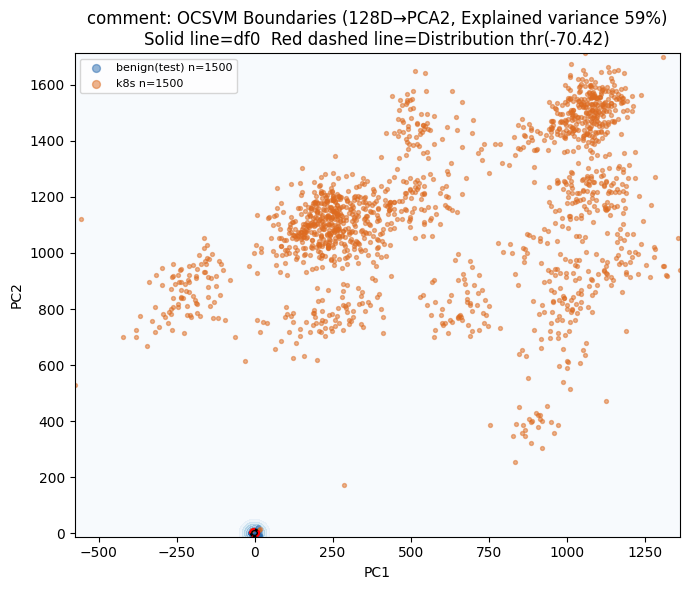

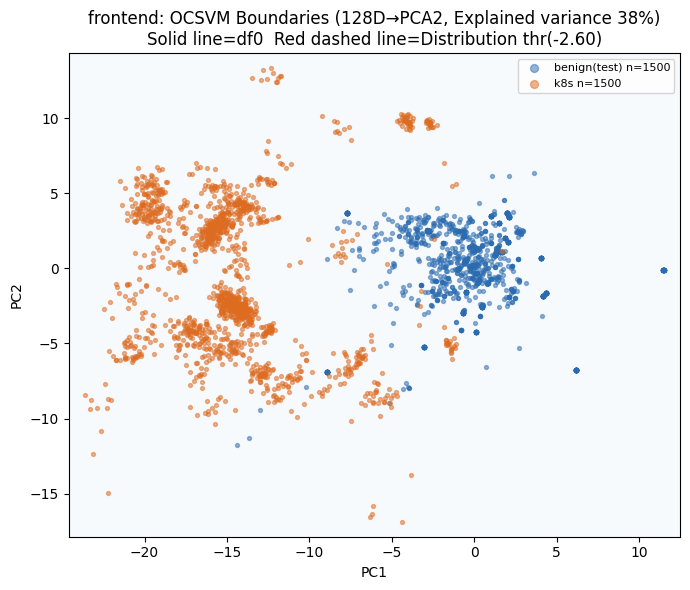

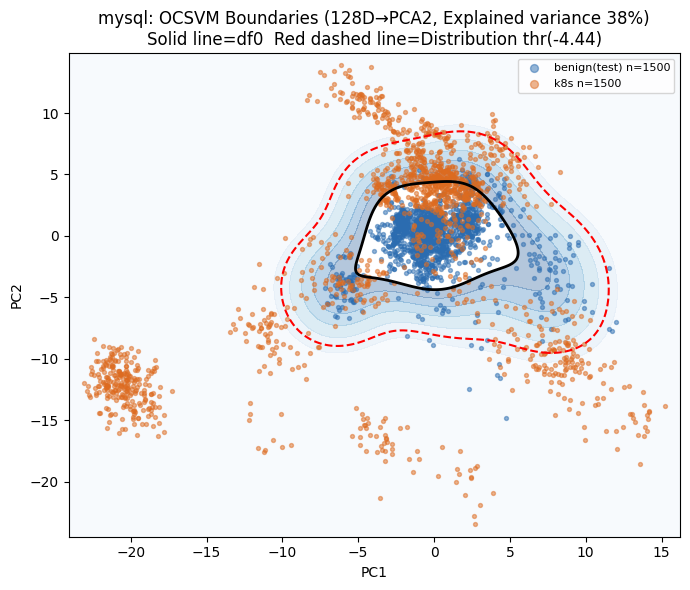

In [ ]:
# 서비스별 OCSVM 결정경계 시각화

import numpy as np, torch, joblib, json, os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from student_cnn import make_student
from data_utils import apply_transport_mask

def load(p):
    X = np.load(p).astype(np.float32); X = X/255 if X.max() > 1.5 else X
    return apply_transport_mask(X)
def emb(m, X, bs=2048):
    m.eval(); out=[]
    with torch.no_grad():
        for i in range(0, len(X), bs):
            out.append(m(torch.from_numpy(X[i:i+bs]).unsqueeze(1)).cpu().numpy())
    return np.concatenate(out)

def plot_svc(svc, attacks, arch='2x8', root='models', cap=1500):
    d = f'{root}/{svc}'
    st = make_student(arch)
    st.load_state_dict(torch.load(f'{d}/student.pth', map_location='cpu')['state_dict'])
    oc  = joblib.load(f'{d}/ocsvm.pkl')
    thr = json.load(open(f'{d}/threshold.json'))['threshold_df']

    # 1) 임베딩(128D)
    Eb = emb(st, load(f'data/{svc}/X_testbenign.npy'))          # test benign
    Ea = {a: emb(st, load(f'data/_attack/X_{a}.npy')) for a in attacks}

    # 2) benign 기준 PCA(2) — 경계 slice의 기준 평면
    pca = PCA(2, random_state=0).fit(Eb)
    rng = np.random.default_rng(0)
    sub = lambda E: E if len(E) <= cap else E[rng.choice(len(E), cap, False)]
    Zb = pca.transform(sub(Eb))
    Za = {a: pca.transform(sub(Ea[a])) for a in attacks}

    # 3) 격자 → inverse_transform(128D) → 실제 배포 OCSVM 평가 (리핏 아님!)
    allz = np.vstack([Zb] + list(Za.values()))
    x0,x1 = allz[:,0].min()-1, allz[:,0].max()+1
    y0,y1 = allz[:,1].min()-1, allz[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x0,x1,300), np.linspace(y0,y1,300))
    zz = oc.decision_function(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape)

    # 4) 그리기
    plt.figure(figsize=(7,6))
    plt.contourf(xx, yy, zz, levels=np.linspace(zz.min(), 0, 7), cmap='Blues', alpha=.3)   # benign 영역(df<0 안쪽)
    plt.contour(xx, yy, zz, levels=[0],   colors='k', linewidths=2)                          # df=0 (기본 컷)
    plt.contour(xx, yy, zz, levels=[thr], colors='r', linewidths=1.5, linestyles='--')       # 배포 threshold
    plt.scatter(Zb[:,0], Zb[:,1], s=8, c='#2b6cb0', alpha=.5, label=f'benign(test) n={len(Zb)}')
    cols = {'brute':'#c53030', 'k8s':'#dd6b20'}
    for a in attacks:
        plt.scatter(Za[a][:,0], Za[a][:,1], s=8, c=cols.get(a,'#666'), alpha=.5, label=f'{a} n={len(Za[a])}')
    var = pca.explained_variance_ratio_.sum()
    plt.title(f'{svc}: OCSVM Boundaries (128D→PCA2, Explained variance {var:.0%})\nSolid line=df0  Red dashed line=Distribution thr({thr:.2f})')
    plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(markerscale=2, fontsize=8); plt.tight_layout()
    os.makedirs('viz_svm', exist_ok=True); plt.savefig(f'viz_svm/{svc}_svm.png', dpi=130); plt.show()

plot_svc('auth', ['brute','k8s'])
for s in ['post','comment','frontend','mysql']: plot_svc(s, ['k8s'])

In [ ]:
!cd /content/training && zip -qr /content/results.zip models viz viz_svm 2>/dev/null && ls -lh /content/results.zip
!cp /content/results.zip /content/drive/MyDrive/

-rw-r--r-- 1 root root 39M Jul 12 21:05 /content/results.zip


In [ ]:
# (선택) 마스킹 OFF ablation
for s in ['auth','post','comment','frontend','mysql']:
    !MASK_TRANSPORT=0 python train_kd_pipeline.py --data data/{s} --out models_nomask/{s} --arch 2x8 --teacher shallow --limit 50000

[pipeline] data/auth → models_nomask/auth | device=cuda | mask=OFF
[마스킹] 전송계층(window/urgptr/seq/ack, rows 7-18) 마스킹 = OFF (MASK_TRANSPORT)
[data] benign total=50000 (sessions=911) → train=34945 val=15055 (세션분할=ON, VEC_LEN=1479)
  [teacher 1/30] nt_xent=2.8916
  [teacher 2/30] nt_xent=1.4700
  [teacher 3/30] nt_xent=1.0587
  [teacher 4/30] nt_xent=0.9278
  [teacher 5/30] nt_xent=0.8701
  [teacher 6/30] nt_xent=0.8164
  [teacher 7/30] nt_xent=0.7786
  [teacher 8/30] nt_xent=0.7645
  [teacher 9/30] nt_xent=0.7545
  [teacher 10/30] nt_xent=0.7442
  [teacher 11/30] nt_xent=0.7402
  [teacher 12/30] nt_xent=0.7366
  [teacher 13/30] nt_xent=0.7336
  [teacher 14/30] nt_xent=0.7289
  [teacher 15/30] nt_xent=0.7277
  [teacher 16/30] nt_xent=0.7274
  [teacher 17/30] nt_xent=0.7219
  [teacher 18/30] nt_xent=0.7229
  [teacher 19/30] nt_xent=0.7206
  [teacher 20/30] nt_xent=0.7191
  [teacher 21/30] nt_xent=0.7181
  [teacher 22/30] nt_xent=0.7156
  [teacher 23/30] nt_xent=0.7145
  [teacher 24/30] nt_x

In [ ]:
# held-out 평가 (test/benign FPR + attack recall)
import numpy as np, torch, joblib, json, os
from student_cnn import make_student
from data_utils import apply_transport_mask
from sklearn.metrics import roc_auc_score
def load(p):
    X=np.load(p).astype(np.float32); X=X/255 if X.max()>1.5 else X
    return apply_transport_mask(X)
def emb(m,X,bs=2048):
    m.eval(); out=[]
    with torch.no_grad():
        for i in range(0,len(X),bs):
            out.append(m(torch.from_numpy(X[i:i+bs]).unsqueeze(1)).cpu().numpy())
    return np.concatenate(out)
def ev(svc, attacks, arch='2x8', root='models'):
    d=f'{root}/{svc}'
    st=make_student(arch); st.load_state_dict(torch.load(f'{d}/student.pth')['state_dict'])
    oc=joblib.load(f'{d}/ocsvm.pkl'); thr=json.load(open(f'{d}/threshold.json'))['threshold_df']
    fb=oc.decision_function(emb(st,load(f'data/{svc}/X_testbenign.npy'))); fpr=float((fb<thr).mean())
    for a in attacks:
        fa=oc.decision_function(emb(st,load(f'data/_attack/X_{a}.npy'))); rec=float((fa<thr).mean())
        auc=roc_auc_score(np.r_[np.zeros(len(fb)),np.ones(len(fa))], np.r_[-fb,-fa])
        print(f'{svc:9} vs {a:6}  ROC-AUC={auc:.3f}  FPR={fpr:.3f}  Recall={rec:.3f}')
ev('auth', ['brute','k8s'])
for s in ['post','comment','frontend','mysql']: ev(s, ['k8s'])

auth      vs brute   ROC-AUC=0.925  FPR=0.116  Recall=0.971
auth      vs k8s     ROC-AUC=0.961  FPR=0.116  Recall=1.000
post      vs k8s     ROC-AUC=1.000  FPR=0.065  Recall=1.000
comment   vs k8s     ROC-AUC=1.000  FPR=0.011  Recall=1.000
frontend  vs k8s     ROC-AUC=0.999  FPR=0.025  Recall=0.997
mysql     vs k8s     ROC-AUC=0.999  FPR=0.010  Recall=0.997


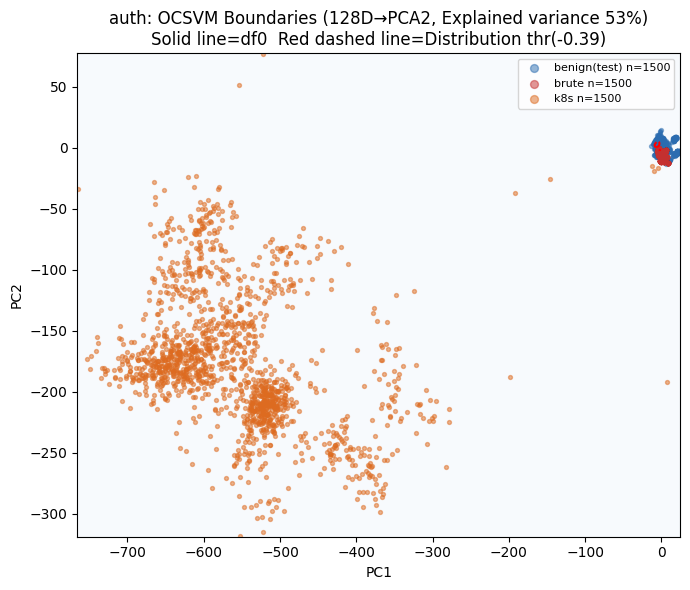

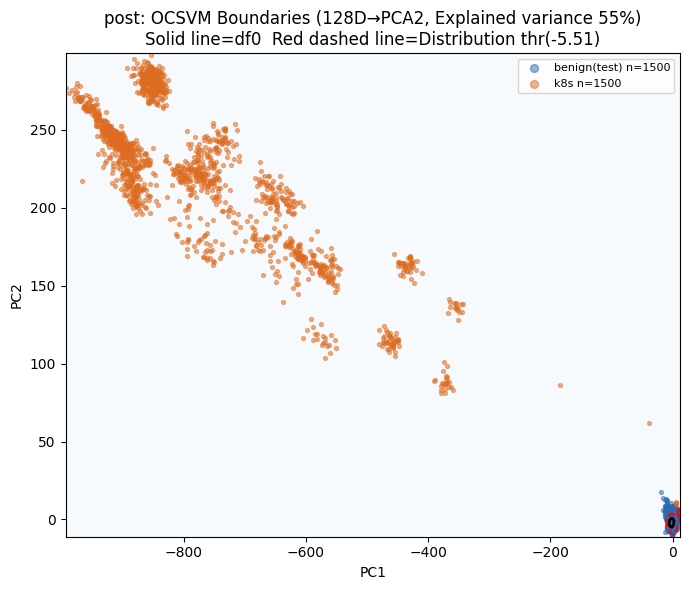

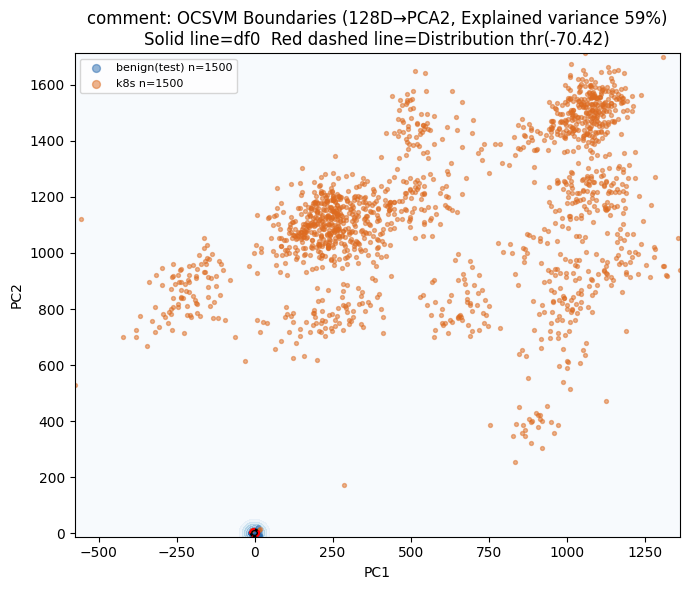

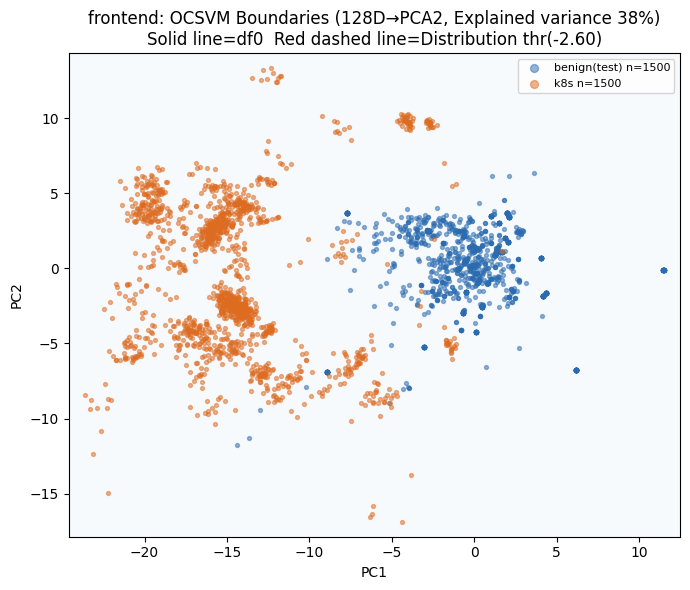

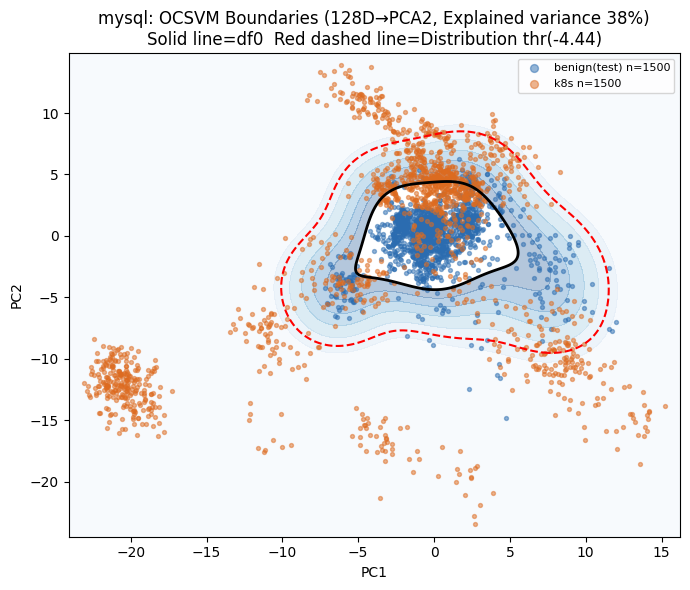

In [ ]:
# 서비스별 OCSVM 결정경계 시각화

import numpy as np, torch, joblib, json, os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from student_cnn import make_student
from data_utils import apply_transport_mask

def load(p):
    X = np.load(p).astype(np.float32); X = X/255 if X.max() > 1.5 else X
    return apply_transport_mask(X)
def emb(m, X, bs=2048):
    m.eval(); out=[]
    with torch.no_grad():
        for i in range(0, len(X), bs):
            out.append(m(torch.from_numpy(X[i:i+bs]).unsqueeze(1)).cpu().numpy())
    return np.concatenate(out)

def plot_svc(svc, attacks, arch='2x8', root='models', cap=1500):
    d = f'{root}/{svc}'
    st = make_student(arch)
    st.load_state_dict(torch.load(f'{d}/student.pth', map_location='cpu')['state_dict'])
    oc  = joblib.load(f'{d}/ocsvm.pkl')
    thr = json.load(open(f'{d}/threshold.json'))['threshold_df']

    # 1) 임베딩(128D)
    Eb = emb(st, load(f'data/{svc}/X_testbenign.npy'))          # test benign
    Ea = {a: emb(st, load(f'data/_attack/X_{a}.npy')) for a in attacks}

    # 2) benign 기준 PCA(2) — 경계 slice의 기준 평면
    pca = PCA(2, random_state=0).fit(Eb)
    rng = np.random.default_rng(0)
    sub = lambda E: E if len(E) <= cap else E[rng.choice(len(E), cap, False)]
    Zb = pca.transform(sub(Eb))
    Za = {a: pca.transform(sub(Ea[a])) for a in attacks}

    # 3) 격자 → inverse_transform(128D) → 실제 배포 OCSVM 평가 (리핏 아님!)
    allz = np.vstack([Zb] + list(Za.values()))
    x0,x1 = allz[:,0].min()-1, allz[:,0].max()+1
    y0,y1 = allz[:,1].min()-1, allz[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x0,x1,300), np.linspace(y0,y1,300))
    zz = oc.decision_function(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape)

    # 4) 그리기
    plt.figure(figsize=(7,6))
    plt.contourf(xx, yy, zz, levels=np.linspace(zz.min(), 0, 7), cmap='Blues', alpha=.3)   # benign 영역(df<0 안쪽)
    plt.contour(xx, yy, zz, levels=[0],   colors='k', linewidths=2)                          # df=0 (기본 컷)
    plt.contour(xx, yy, zz, levels=[thr], colors='r', linewidths=1.5, linestyles='--')       # 배포 threshold
    plt.scatter(Zb[:,0], Zb[:,1], s=8, c='#2b6cb0', alpha=.5, label=f'benign(test) n={len(Zb)}')
    cols = {'brute':'#c53030', 'k8s':'#dd6b20'}
    for a in attacks:
        plt.scatter(Za[a][:,0], Za[a][:,1], s=8, c=cols.get(a,'#666'), alpha=.5, label=f'{a} n={len(Za[a])}')
    var = pca.explained_variance_ratio_.sum()
    plt.title(f'{svc}: OCSVM Boundaries (128D→PCA2, Explained variance {var:.0%})\nSolid line=df0  Red dashed line=Distribution thr({thr:.2f})')
    plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(markerscale=2, fontsize=8); plt.tight_layout()
    os.makedirs('viz_svm', exist_ok=True); plt.savefig(f'viz_svm/{svc}_svm.png', dpi=130); plt.show()

plot_svc('auth', ['brute','k8s'])
for s in ['post','comment','frontend','mysql']: plot_svc(s, ['k8s'])

In [ ]:
!cd /content/training && zip -qr /content/results2.zip models viz viz_svm 2>/dev/null && ls -lh /content/results2.zip
!cp /content/results2.zip /content/drive/MyDrive/

-rw-r--r-- 1 root root 39M Jul 12 23:52 /content/results2.zip
